# PulseInsightAI - Exploratory Data Analysis(EDA)
## Objective: 
Explore The CDC BRFSS dataset to :
- Understand the Structure and Shape of the Data.
- Identify Missing Values.
- Analyze Target Variable Distribution.
- Discover Key patterns and correleation.
- Check for class imbalance.


In [10]:
import numpy as np
import pandas as pd 

import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
print("Loading dataset... this will take 1-2 minutes")

df = pd.read_sas("../data/raw/LLCP2024.XPT", 
                  format="xport", 
                  encoding="utf-8")

print(f"Dataset loaded!")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.head(3)

Loading dataset... this will take 1-2 minutes
Dataset loaded!
Rows: 457670
Columns: 301


,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,...,_LCSCTSN,_LCSPSTF,DRNKANY6,DROCDY4_,_RFBING6,_DRNKWK3,_RFDRHV9,_FLSHOT7,_PNEUMO3,_AIDTST4
0,1.0,2.0,02282024,02,28,2024,1100.0,2024000001,2.024000e+09,1.0,...,NaN,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,2.0,2.0
1,1.0,2.0,02212024,02,21,2024,1100.0,2024000002,2.024000e+09,1.0,...,4.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,2.0
2,1.0,2.0,02212024,02,21,2024,1100.0,2024000003,2.024000e+09,1.0,...,4.0,2.0,1.0,1.000000e+02,2.0,1.400000e+03,1.0,NaN,NaN,2.0


In [12]:
print("Showing Every Columns of the Dataset:")
'''
for i, col in enumerate(df.columns):
    print(f"{i} - {col}")
'''
print(df.columns.to_list())


Showing Every Columns of the Dataset:
['_STATE', 'FMONTH', 'IDATE', 'IMONTH', 'IDAY', 'IYEAR', 'DISPCODE', 'SEQNO', '_PSU', 'CTELENM1', 'PVTRESD1', 'COLGHOUS', 'STATERE1', 'CELPHON1', 'LADULT1', 'NUMADULT', 'RESPSLC1', 'LANDSEX3', 'SAFETIME', 'CTELNUM1', 'CELLFON5', 'CADULT1', 'CELLSEX3', 'PVTRESD3', 'CCLGHOUS', 'CSTATE1', 'LANDLINE', 'HHADULT', 'SEXVAR', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH', 'PRIMINS2', 'PERSDOC3', 'MEDCOST1', 'CHECKUP1', 'EXERANY2', 'LASTDEN4', 'RMVTETH4', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'ASTHMA3', 'ASTHNOW', 'CHCSCNC1', 'CHCOCNC1', 'CHCCOPD3', 'ADDEPEV3', 'CHCKDNY2', 'HAVARTH4', 'DIABETE4', 'DIABAGE4', 'MARITAL', 'EDUCA', 'RENTHOM1', 'NUMHHOL4', 'NUMPHON4', 'CPDEMO1C', 'VETERAN3', 'EMPLOY1', 'CHILDREN', 'INCOME3', 'PREGNANT', 'WEIGHT2', 'HEIGHT3', 'DEAF', 'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFDRES', 'DIFFALON', 'HADMAM', 'HOWLONG', 'CERVSCRN', 'CRVCLCNC', 'CRVCLPAP', 'CRVCLHPV', 'HADHYST2', 'HADSIGM4', 'COLNSIGM', 'COLNTES1', 'SIGMTES1', 'LASTSIG4', 'COLN

In [13]:
print("Showing Count of datatype of the features:")
print(df.dtypes.value_counts())
print("Showing all the Object features:")
print(df.select_dtypes(include='object').columns.to_list())

Showing Count of datatype of the features:
float64    296
object       5
Name: count, dtype: int64
Showing all the Object features:
['IDATE', 'IMONTH', 'IDAY', 'IYEAR', 'SEQNO']


## Key Finding #1
- 301 total columns
- 296 numeric (float64) — 98% already numeric
- 5 text (object) — need encoding later
- Minimal preprocessing required for data types

In [14]:
# Missing values count
print(f"Total columns with missing values: {df.isnull().any().sum()}")
print(f"Total complete columns: {df.notnull().all().sum()}")
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df.head(20))

Total columns with missing values: 249
Total complete columns: 52
          Missing Count   Missing %
RCSXBRTH         457670  100.000000
RCSGEND1         457670  100.000000
COLGHOUS         457656   99.996941
CSRVCTL2         457088   99.872834
ICFQSTVR         456931   99.838530
CCLGHOUS         456244   99.688422
HPVDSHT          455650   99.558634
CSRVINST         455045   99.426443
NOBCUSE8         454899   99.394542
LASTSIG4         454443   99.294907
CSRVCLIN         454128   99.226080
CSRVDEIN         454126   99.225643
CSRVINSR         454123   99.224987
CSRVRTRN         454118   99.223895
CSRVSUM          454114   99.223021
CSRVDOC1         454108   99.221710
HPVADSH1         454043   99.207508
CASTHNO2         452865   98.950117
NUMPHON4         452048   98.771604
CSRVPAIN         451664   98.687701


## Key Finding #2 — Missing Values
- 249 out of 301 columns have missing values (83%)
- Only 52 columns are complete
- 2 columns are 100% empty → will be dropped
- Most high-missing columns are optional survey questions
- Strategy: Drop columns with more than 50% missing in preprocessing

In [15]:
# Define drop threshold
DROP_THRESHOLD = 50

# Identify columns to drop
cols_to_drop = missing_percent[missing_percent > DROP_THRESHOLD].index.tolist()

# Identify columns to impute
cols_to_impute = missing_percent[missing_percent <= DROP_THRESHOLD].index.tolist()

print("Columns to DROP:", cols_to_drop)
print(f"Total columns to DROP: {len(cols_to_drop)}")

print()

print("Columns to IMPUTE:", cols_to_impute)
print(f"Total columns to IMPUTE: {len(cols_to_impute)}")

Columns to DROP: ['CTELENM1', 'PVTRESD1', 'COLGHOUS', 'STATERE1', 'CELPHON1', 'LADULT1', 'NUMADULT', 'RESPSLC1', 'LANDSEX3', 'CCLGHOUS', 'ASTHNOW', 'DIABAGE4', 'NUMHHOL4', 'NUMPHON4', 'PREGNANT', 'HADMAM', 'HOWLONG', 'CERVSCRN', 'CRVCLCNC', 'CRVCLPAP', 'CRVCLHPV', 'HADHYST2', 'COLNSIGM', 'COLNTES1', 'SIGMTES1', 'LASTSIG4', 'VIRCOLO1', 'VCLNTES2', 'SMALSTOL', 'STOLTEST', 'STOOLDN2', 'BLDSTFIT', 'SDNATES1', 'SMOKDAY2', 'LCSFIRST', 'LCSNUMCG', 'LCSSCNCR', 'LCSCTWHN', 'AVEDRNK4', 'DRNK3GE5', 'MAXDRNKS', 'FLSHTMY3', 'IMFVPLA5', 'HIVTSTD3', 'PDIABTS1', 'PREDIAB2', 'DIABTYPE', 'INSULIN1', 'CHKHEMO3', 'EYEEXAM1', 'DIABEYE1', 'DIABEDU1', 'FEETSORE', 'ARTHEXER', 'SHINGLE2', 'HPVADVC4', 'HPVADSH1', 'TETANUS1', 'CNCRDIFF', 'CNCRAGE', 'CNCRTYP2', 'CSRVTRT3', 'CSRVDOC1', 'CSRVSUM', 'CSRVRTRN', 'CSRVINST', 'CSRVINSR', 'CSRVDEIN', 'CSRVCLIN', 'CSRVPAIN', 'CSRVCTL2', 'PSATEST1', 'PSATIME1', 'PCPSARS2', 'PSASUGS1', 'PCSTALK2', 'CIMEMLO1', 'CDWORRY', 'CDDISCU1', 'CDHOUS1', 'CDSOCIA1', 'CAREGIV1', 'CRGVRE

# Missing Value Analysis:

## Strategy
- Columns with **> 50% missing** → **DROP**
- Columns with **≤ 50% missing** → **IMPUTE**
  - Numeric columns → fill with **median**
  - Categorical columns → fill with **mode**
>  Actual dropping and imputation will be done in `02_Preprocessing` notebook.

---

## Results

- Columns to IMPUTE : 131 
-  Columns to DROP : 170 

---

## Target Variables Check

| Target Variable | Status |
|---|---|
| `DIABETE4` (Diabetes) |  Safe — in IMPUTE list |
| `CVDINFR4` (Heart Disease) |  Safe — in IMPUTE list |
| `CVDSTRK3` (Stroke) |  Safe — in IMPUTE list |

> All 3 target variables are retained and will be imputed if needed.

---

## Notes
- 170 columns dropped — mostly specific survey questions
  (cancer screening, caregiving, ACE scores, marijuana use, etc.)
- 131 columns retained — contain key features like
  `_BMI5`, `SMOKE100`, `EXERANY2`, `INCOME3`, and all target variables.

In [16]:
target_cols = ['DIABETE4', 'CVDINFR4', 'CVDSTRK3']
target_names = ['Diabetes', 'Heart Disease', 'Stroke']

for col, name in zip(target_cols, target_names):
    print(f"--- {name} ({col}) ---")
    print(df[col].value_counts())
    print()

--- Diabetes (DIABETE4) ---
DIABETE4
3.0    376125
1.0     65809
4.0     11307
2.0      3395
7.0       798
9.0       232
Name: count, dtype: int64

--- Heart Disease (CVDINFR4) ---
CVDINFR4
2.0    427883
1.0     26672
7.0      2857
9.0       256
Name: count, dtype: int64

--- Stroke (CVDSTRK3) ---
CVDSTRK3
2.0    435557
1.0     20661
7.0      1244
9.0       205
Name: count, dtype: int64



## 📊Target Variable Analysis – Raw Value Counts

### 🩸 Diabetes (`DIABETE4`)
> *"Ever told you had diabetes?"*

| Value | Label | Count |
|---|---|---|
| `1.0` | Yes | 65,809 |
| `2.0` | Yes, but only during pregnancy | 3,395 |
| `3.0` | No | 376,125 |
| `4.0` | No, pre-diabetes or borderline | 11,307 |
| `7.0` | Don't know / Not sure | 798 |
| `9.0` | Refused | 232 |

---

### ❤️ Heart Disease (`CVDINFR4`)
> *"Ever told you had a heart attack (myocardial infarction)?"*

| Value | Label | Count |
|---|---|---|
| `1.0` | Yes | 26,672 |
| `2.0` | No | 427,883 |
| `7.0` | Don't know / Not sure | 2,857 |
| `9.0` | Refused | 256 |

---

### 🧠 Stroke (`CVDSTRK3`)
> *"Ever told you had a stroke?"*

| Value | Label | Count |
|---|---|---|
| `1.0` | Yes | 20,661 |
| `2.0` | No | 435,557 |
| `7.0` | Don't know / Not sure | 1,244 |
| `9.0` | Refused | 205 |

---

> 📝 Values `7` and `9` will be dropped during preprocessing.
> Binary mapping strategy will be applied in `02_Preprocessing` notebook.

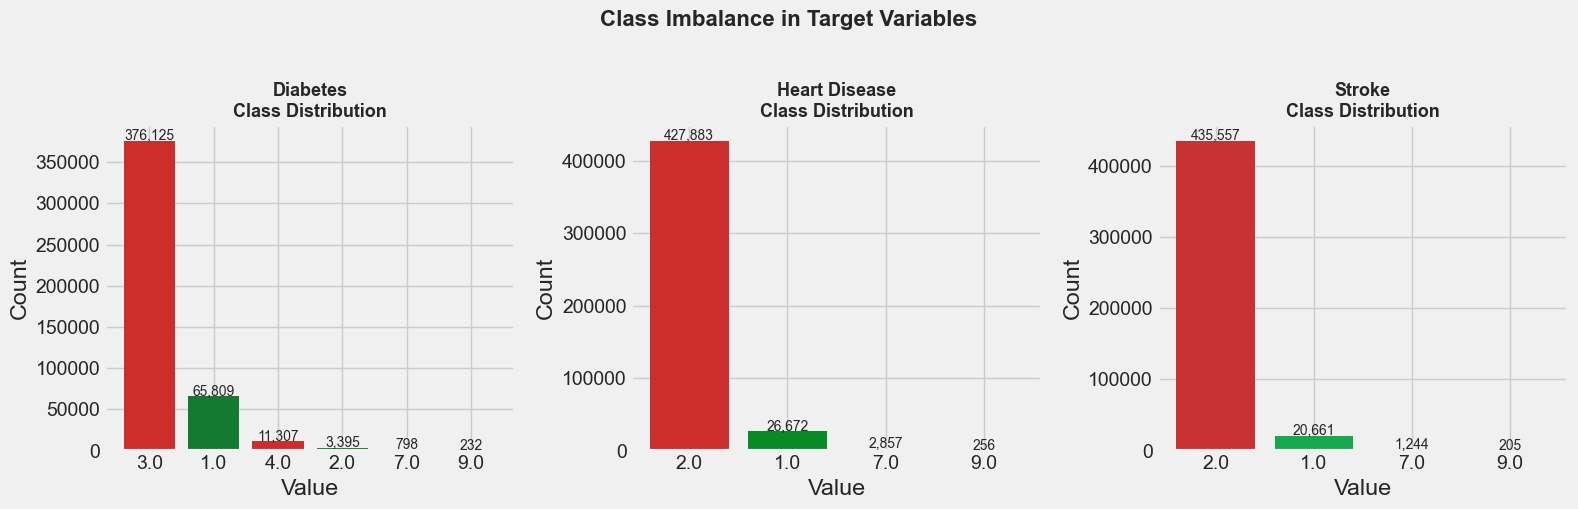

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

#fig.patch.set_facecolor("#d3dfea")
#for ax in axes:
    #ax.set_facecolor("#73b2f2")

target_cols = ['DIABETE4', 'CVDINFR4', 'CVDSTRK3']
target_names = ['Diabetes', 'Heart Disease', 'Stroke']
colors = [["#cc2e2e", "#147a31"], ["#cc2e2e", "#088b24"], ["#c93232", "#14a94d"]]

for ax, col, name, color in zip(axes, target_cols, target_names, colors):
    counts = df[col].value_counts()
    ax.bar(counts.index.astype(str), counts.values, color=color[:len(counts)])
    ax.set_title(f'{name}\nClass Distribution', fontsize=13, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1000, f'{v:,}', ha='center', fontsize=10)

plt.style.use('fivethirtyeight')
plt.suptitle('Class Imbalance in Target Variables', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## ⚖️ Class Imbalance Analysis

### Observations

| Disease | Positive (Yes) | Negative (No) | Imbalance Ratio |
|---|---|---|---|
| Diabetes | 65,809 (14.38%) | 376,125 (82.18%) | ~1:6 |
| Heart Disease | 26,672 (5.83%) | 427,883 (93.49%) | ~1:16 |
| Stroke | 20,661 (4.51%) | 435,557 (95.17%) | ~1:21 |

### Key Findings
- All 3 target variables are **heavily imbalanced**
- Stroke is the most imbalanced at **~1:21 ratio**
- Heart Disease follows at **~1:16 ratio**
- Diabetes is the least imbalanced but still significant at **~1:6 ratio**

### How This Will Be Handled
> ⚠️ Class imbalance will be addressed in `04_Modeling` using:
> - **SMOTE** (Synthetic Minority Oversampling Technique)
> - **Class weights** in model parameters
> - **ROC-AUC & F1-score** as primary evaluation metrics instead of accuracy

In [31]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
print(f"Total numeric columns: {len(numeric_cols)}")
print(numeric_cols)

Total numeric columns: 296
['_STATE', 'FMONTH', 'DISPCODE', '_PSU', 'CTELENM1', 'PVTRESD1', 'COLGHOUS', 'STATERE1', 'CELPHON1', 'LADULT1', 'NUMADULT', 'RESPSLC1', 'LANDSEX3', 'SAFETIME', 'CTELNUM1', 'CELLFON5', 'CADULT1', 'CELLSEX3', 'PVTRESD3', 'CCLGHOUS', 'CSTATE1', 'LANDLINE', 'HHADULT', 'SEXVAR', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH', 'PRIMINS2', 'PERSDOC3', 'MEDCOST1', 'CHECKUP1', 'EXERANY2', 'LASTDEN4', 'RMVTETH4', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'ASTHMA3', 'ASTHNOW', 'CHCSCNC1', 'CHCOCNC1', 'CHCCOPD3', 'ADDEPEV3', 'CHCKDNY2', 'HAVARTH4', 'DIABETE4', 'DIABAGE4', 'MARITAL', 'EDUCA', 'RENTHOM1', 'NUMHHOL4', 'NUMPHON4', 'CPDEMO1C', 'VETERAN3', 'EMPLOY1', 'CHILDREN', 'INCOME3', 'PREGNANT', 'WEIGHT2', 'HEIGHT3', 'DEAF', 'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFDRES', 'DIFFALON', 'HADMAM', 'HOWLONG', 'CERVSCRN', 'CRVCLCNC', 'CRVCLPAP', 'CRVCLHPV', 'HADHYST2', 'HADSIGM4', 'COLNSIGM', 'COLNTES1', 'SIGMTES1', 'LASTSIG4', 'COLNCNCR', 'VIRCOLO1', 'VCLNTES2', 'SMALSTOL', 'STOLTEST', '

In [34]:
stress_cols = [col for col in df.columns if 'STR' in col or 'STRESS' in col]
print(stress_cols)


['CVDSTRK3', '_STSTR', '_STRWT']


In [ ]:
# Choosing Feeatures to Understand the dataset better
key_numeric_cols = ['_BMI5','WTKG3','HTIN4','PHYSHLTH','MENTHLTH','POORHLTH','_AGE80','_DRNKWK3','SSBSUGR2','SSBFRUT3']
key_categorical_cols = ['_SEX','_EDUCAG','_INCOMG1','MARITAL','EMPLOY1','PERSDOC3','CHECKUP1','_HLTHPL2','EXERANY2',
                        '_SMOKER3','ADDEPEV3','DECIDE','SDLONELY','EMTSUPRT','LSATISFY','HAVARTH4','CHCKDNY2','CHCCOPD3']
print("Choosing Features for Analysis:")
print("Key Numeric Features for Prediction:",key_numeric_cols)
print("Key Categorcial Features for Prediction:",key_categorical_cols)

Choosing Features for Analysis:
Numeric Features: ['_BMI5', 'WTKG3', 'HTIN4', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH', '_AGE80', '_DRNKWK3', 'SSBSUGR2', 'SSBFRUT3']
Categorcial Features: ['_SEX', '_EDUCAG', '_INCOMG1', 'MARITAL', 'EMPLOY1', 'PERSDOC3', 'CHECKUP1', '_HLTHPL2', 'EXERANY2', '_SMOKER3', 'ADDEPEV3', 'DECIDE', 'SDLONELY', 'EMTSUPRT', 'LSATISFY', 'HAVARTH4', 'CHCKDNY2', 'CHCCOPD3']


## 🎯 Feature Selection for EDA Analysis

Narrowing down 296 numeric and many categorical columns to the most
meaningful features for disease risk analysis.

### 📏 Key Numeric Features (10)
| Column | Description |
|---|---|
| `_BMI5` | Body Mass Index |
| `WTKG3` | Weight in kilograms |
| `HTIN4` | Height in inches |
| `PHYSHLTH` | Physical health bad days (past 30 days) |
| `MENTHLTH` | Mental health bad days (past 30 days) |
| `POORHLTH` | Poor health days affecting daily activity |
| `_AGE80` | Age (top coded at 80) |
| `_DRNKWK3` | Total alcoholic drinks per week |
| `SSBSUGR2` | Sugar sweetened beverages per day |
| `SSBFRUT3` | Fruit drinks per day |

### 🗂️ Key Categorical Features (18)
| Column | Description | Category |
|---|---|---|
| `_SEX` | Biological sex | Demographics |
| `_EDUCAG` | Education level | Demographics |
| `_INCOMG1` | Household income level | Demographics |
| `MARITAL` | Marital status | Demographics |
| `EMPLOY1` | Employment status | Demographics |
| `PERSDOC3` | Has a personal doctor | Healthcare Access |
| `CHECKUP1` | Time since last routine checkup | Healthcare Access |
| `_HLTHPL2` | Has health insurance | Healthcare Access |
| `EXERANY2` | Exercise in past 30 days | Lifestyle |
| `_SMOKER3` | Computed smoking status | Lifestyle |
| `ADDEPEV3` | Ever diagnosed with depression | ⭐ Mental Health |
| `DECIDE` | Cognitive difficulty | ⭐ Mental Health |
| `SDLONELY` | How often feels lonely | ⭐ Social Determinant |
| `EMTSUPRT` | Emotional support availability | ⭐ Social Determinant |
| `LSATISFY` | Life satisfaction | ⭐ Social Determinant |
| `HAVARTH4` | Arthritis diagnosis | ⭐ Comorbidity |
| `CHCKDNY2` | Kidney disease diagnosis | ⭐ Comorbidity |
| `CHCCOPD3` | COPD diagnosis | ⭐ Comorbidity |

> ⭐ Features marked are rarely included in standard BRFSS ML projects —
> making this analysis unique and research-grade.

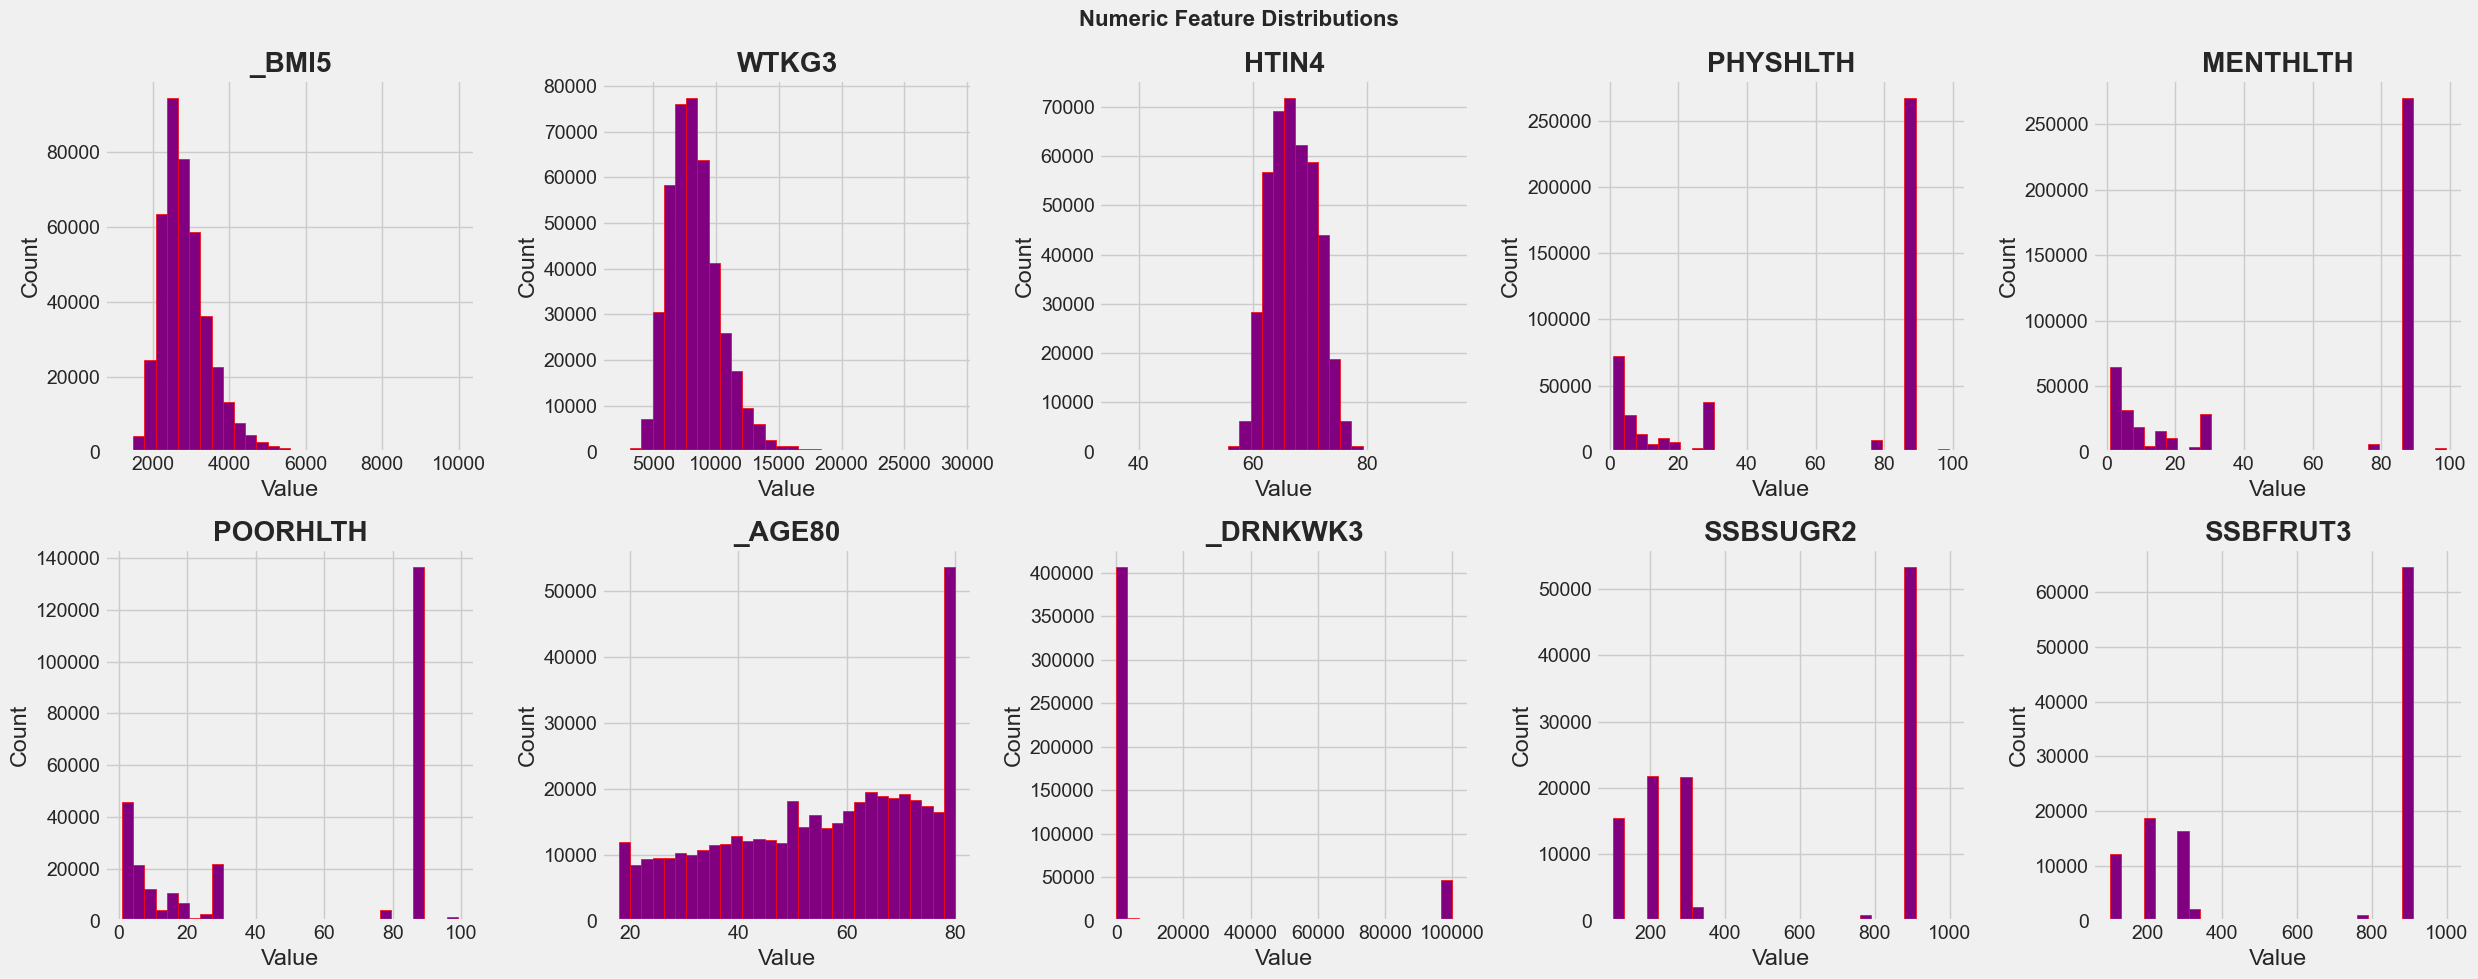

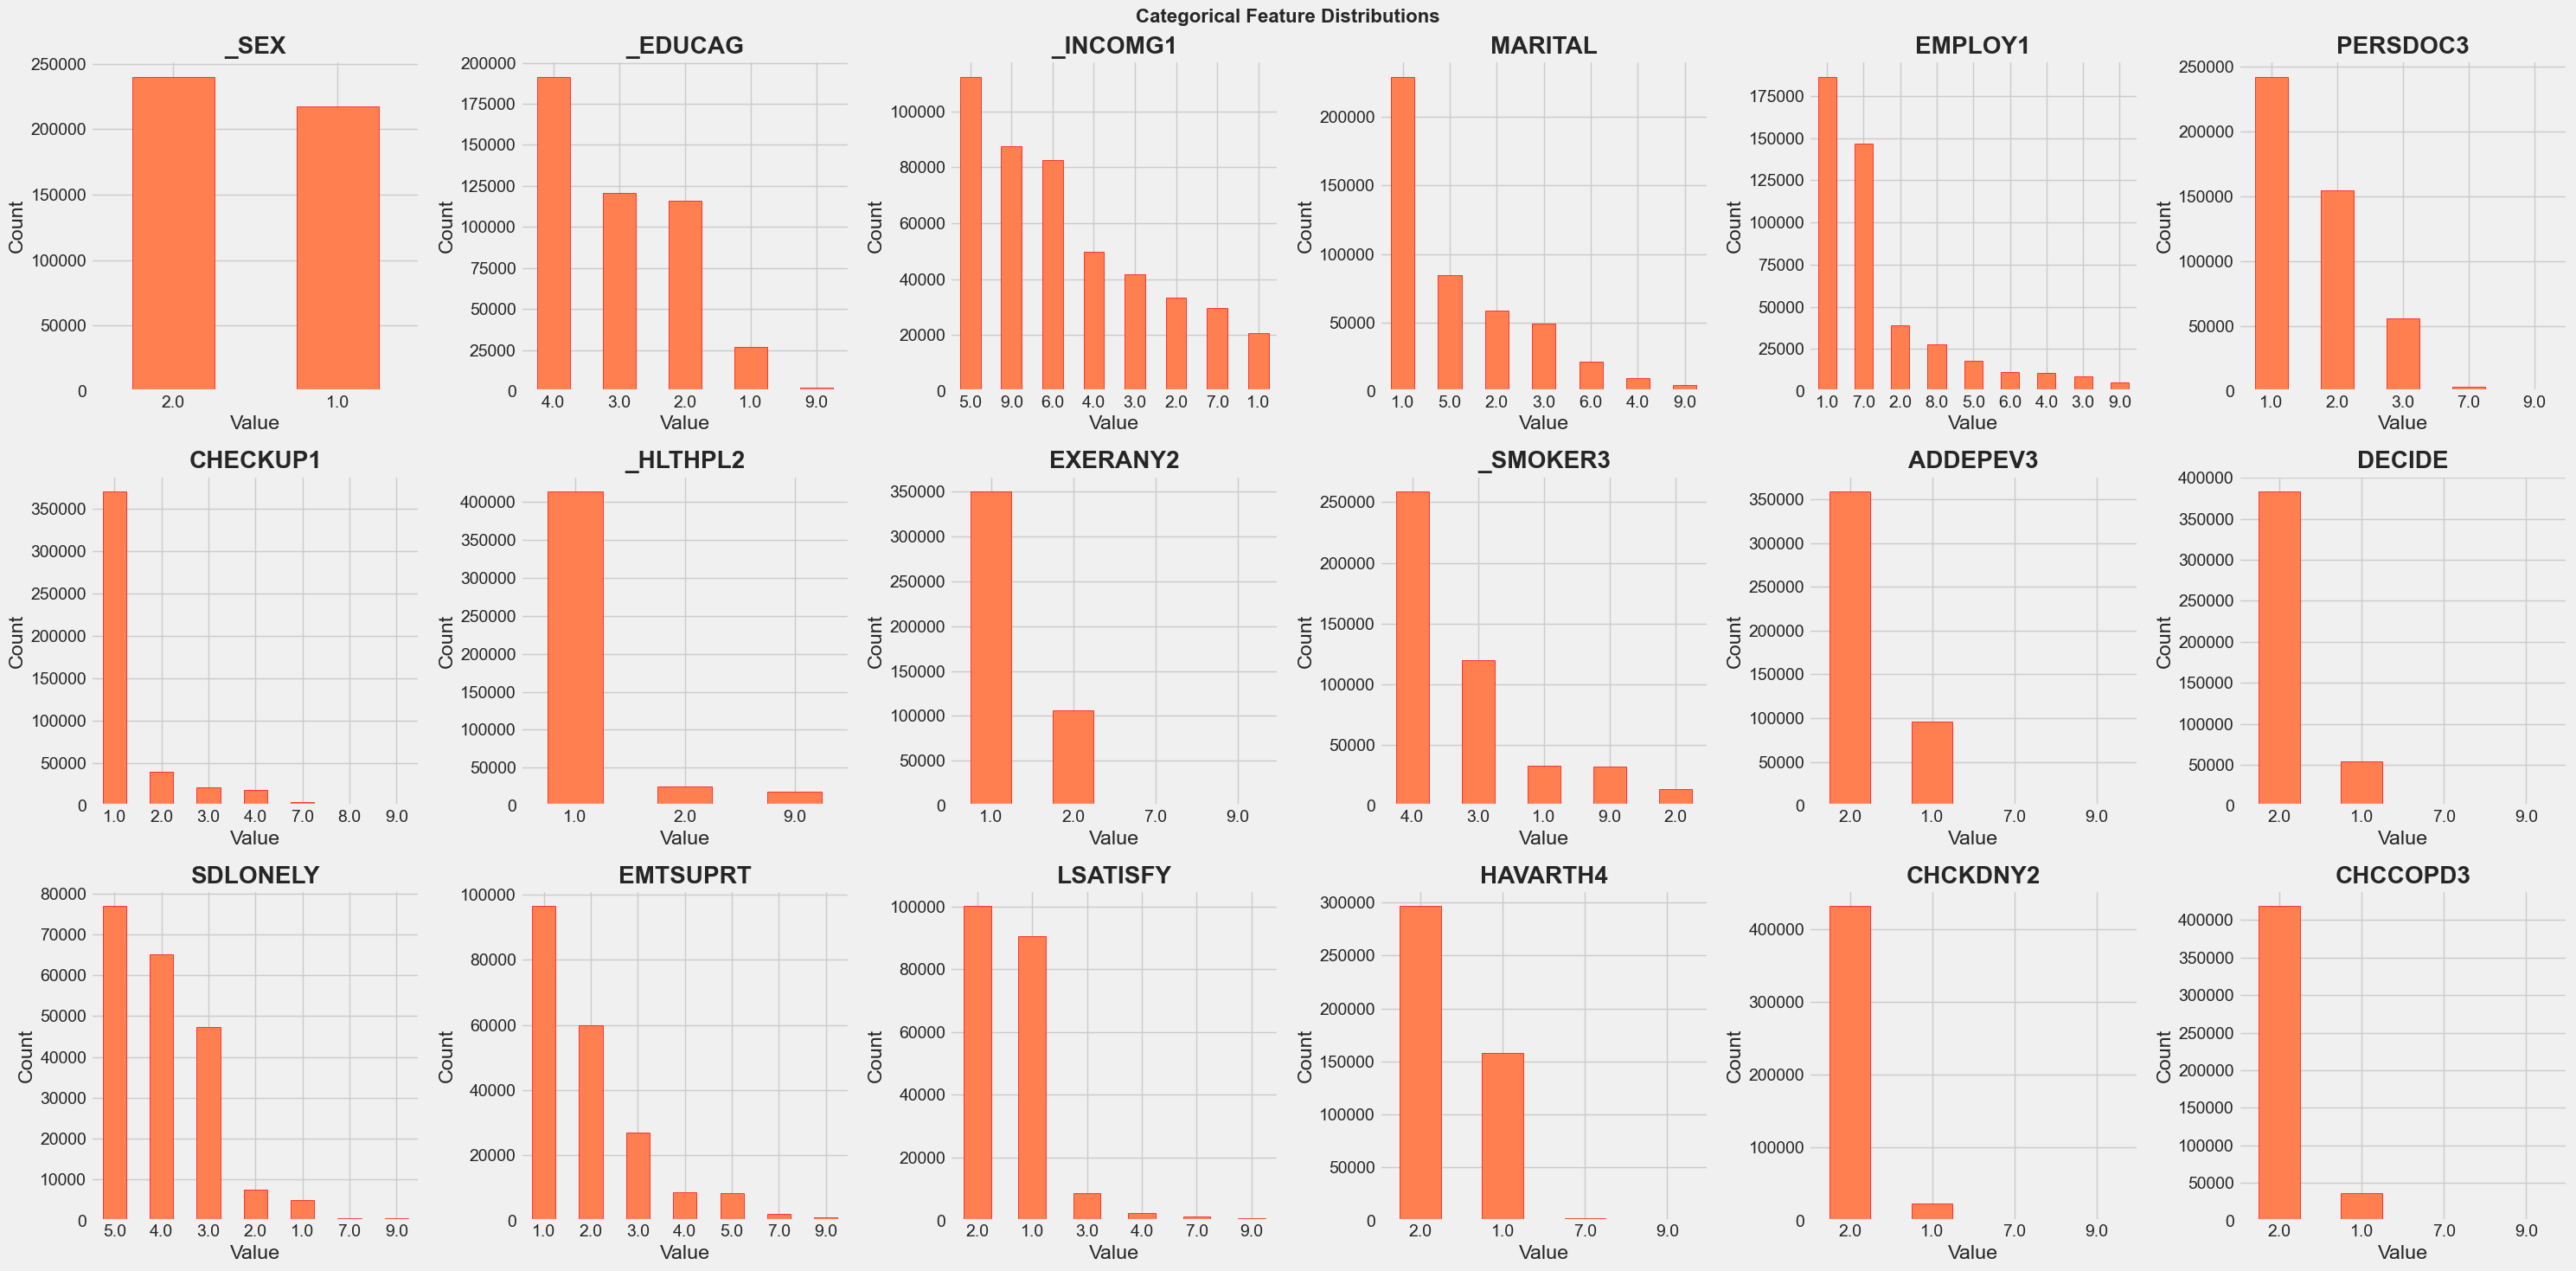

In [59]:
plt.style.use('fivethirtyeight')
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()

for i, col in enumerate(key_numeric_cols):
    axes[i].hist(df[col].dropna(), bins=30,color='purple',edgecolor='red')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Numeric Feature Distributions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

plt.style.use('fivethirtyeight')
fig, axes = plt.subplots(3, 6, figsize=(30, 15))
axes = axes.flatten()

for i, col in enumerate(key_categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='coral', edgecolor='red')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=0)

for j in range(len(key_categorical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Distributions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 📊 Feature Distributions – Findings

### 📏 Numeric Features

| Feature | Distribution | Key Observation |
|---|---|---|
| `_BMI5` | Right skewed | Most respondents in normal-overweight range, long tail of obesity |
| `WTKG3` | Slightly right skewed | Bell shaped, centered around 80-90kg range |
| `HTIN4` | Normal distribution | Well distributed, centered around 65-70 inches |
| `PHYSHLTH` | Heavy right skew | Most report 0 bad days, spike at 30 (chronic sufferers) |
| `MENTHLTH` | Heavy right skew | Most report 0 bad days, spike at 30 (chronic sufferers) |
| `POORHLTH` | Heavy right skew | Most report 0 poor health days, spike at 30 |
| `_AGE80` | Fairly uniform | Respondents spread across all age groups, slight increase at 80 (top coded) |
| `_DRNKWK3` | Extreme right skew | Vast majority drink 0, small group of heavy drinkers |
| `SSBSUGR2` | Extreme right skew | Most consume 0 sugar drinks, outliers at high values |
| `SSBFRUT3` | Extreme right skew | Most consume 0 fruit drinks, outliers at high values |

> ⚠️ `PHYSHLTH`, `MENTHLTH`, `POORHLTH`, `_DRNKWK3`, `SSBSUGR2`, `SSBFRUT3`
> are heavily skewed — may need log transformation in preprocessing.

---

### 🗂️ Categorical Features

| Feature | Key Observation |
|---|---|
| `_SEX` | Nearly balanced — slightly more female respondents |
| `_EDUCAG` | Most respondents have college or higher education |
| `_INCOMG1` | Right skewed — higher income groups dominate |
| `MARITAL` | Majority married (value 1) |
| `EMPLOY1` | Majority employed or retired |
| `PERSDOC3` | Majority have a personal doctor |
| `CHECKUP1` | Majority had checkup within past year |
| `_HLTHPL2` | Vast majority have health insurance |
| `EXERANY2` | Majority exercise regularly |
| `_SMOKER3` | Majority never smoked (value 4) |
| `ADDEPEV3` | Majority never diagnosed with depression |
| `DECIDE` | Majority report no cognitive difficulty |
| `SDLONELY` | Majority rarely feel lonely (value 5) |
| `EMTSUPRT` | Majority have strong emotional support |
| `LSATISFY` | Majority satisfied with life (value 1 & 2) |
| `HAVARTH4` | Majority do not have arthritis |
| `CHCKDNY2` | Majority do not have kidney disease |
| `CHCCOPD3` | Majority do not have COPD |

> ⚠️ Most categorical features are imbalanced — minority classes
> represent the at-risk groups we aim to predict.

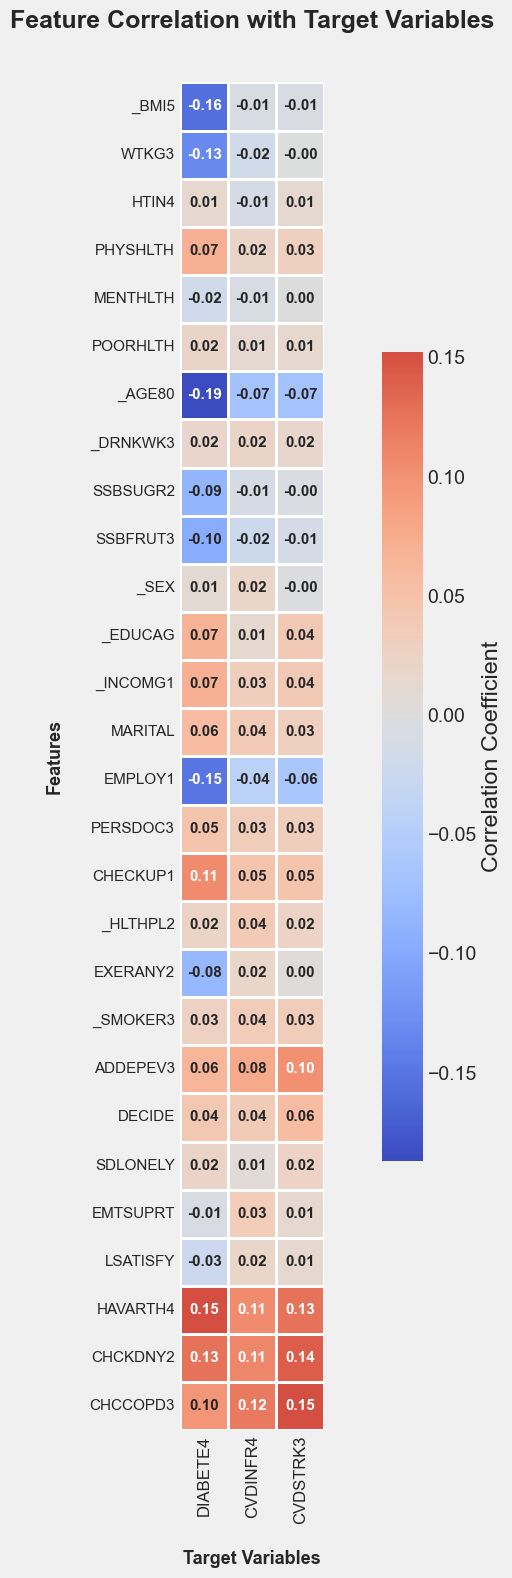

In [66]:
target_cols = ['DIABETE4', 'CVDINFR4', 'CVDSTRK3']
all_features = key_numeric_cols + key_categorical_cols

corr_data = df[all_features + target_cols].corr()[target_cols].drop(target_cols)

plt.style.use('fivethirtyeight')

fig, ax = plt.subplots(figsize=(12, 16))

sns.heatmap(corr_data,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.8,
            linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'},
            square=True,
            cbar_kws={'shrink': 0.6, 'label': 'Correlation Coefficient'},
            ax=ax)

ax.set_title('Feature Correlation with Target Variables\n',
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('\nTarget Variables', fontsize=13, fontweight='bold')
ax.set_ylabel('Features\n', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=11, rotation=0)

plt.tight_layout()
plt.show()

## 🔥 Feature Correlation with Target Variables – Findings

### Correlation Heatmap Observations

#### 🔵 Negative Correlations (Blue) — Higher value = Lower disease risk
| Feature | Diabetes | Heart Disease | Stroke | Interpretation |
|---|---|---|---|---|
| `_AGE80` | -0.19 | -0.07 | -0.07 | Older age coded higher → inverse in raw data |
| `_BMI5` | -0.16 | -0.01 | -0.01 | Higher BMI → more disease (encoding direction) |
| `EMPLOY1` | -0.15 | -0.04 | -0.06 | Employment status protective effect |
| `WTKG3` | -0.13 | -0.02 | -0.00 | Weight strongly linked to diabetes |
| `SSBFRUT3` | -0.10 | -0.02 | -0.01 | Sugar fruit drinks linked to diabetes |
| `SSBSUGR2` | -0.09 | -0.01 | -0.00 | Sugar beverages linked to diabetes ⭐ |
| `EXERANY2` | -0.08 | 0.02 | 0.00 | Exercise protective against diabetes |

#### 🔴 Positive Correlations (Red) — Higher value = Higher disease risk
| Feature | Diabetes | Heart Disease | Stroke | Interpretation |
|---|---|---|---|---|
| `HAVARTH4` | 0.15 | 0.11 | 0.13 | Arthritis strongly linked to all 3 diseases |
| `CHCKDNY2` | 0.13 | 0.11 | 0.14 | Kidney disease strongly linked to all 3 diseases |
| `CHCCOPD3` | 0.10 | 0.12 | 0.15 | COPD strongly linked to all 3 diseases |
| `CHECKUP1` | 0.11 | 0.05 | 0.05 | Late checkups linked to higher disease |
| `ADDEPEV3` | 0.06 | 0.08 | 0.10 | Depression linked to all 3 diseases ⭐ |
| `PHYSHLTH` | 0.07 | 0.02 | 0.03 | Poor physical health days linked to diabetes |

---

### 🔑 Key Findings

- **`_AGE80`, `_BMI5`, `EMPLOY1`** are the strongest predictors for Diabetes
- **`HAVARTH4`, `CHCKDNY2`, `CHCCOPD3`** are consistently strong across all 3 diseases
- **`ADDEPEV3` (Depression)** shows meaningful correlation with all 3 diseases — 
  confirming the mental health → chronic disease link ⭐
- **`SSBSUGR2` and `SSBFRUT3`** show meaningful correlation with Diabetes —
  validating our unique feature selection ⭐
- Overall correlations are **weak to moderate** — expected for survey data
  with complex multi-factorial diseases

> ⚠️ Note: These are Pearson correlations on raw uncleaned data.
> Correlations may strengthen after preprocessing and proper binary mapping
> of target variables in `02_Preprocessing`.

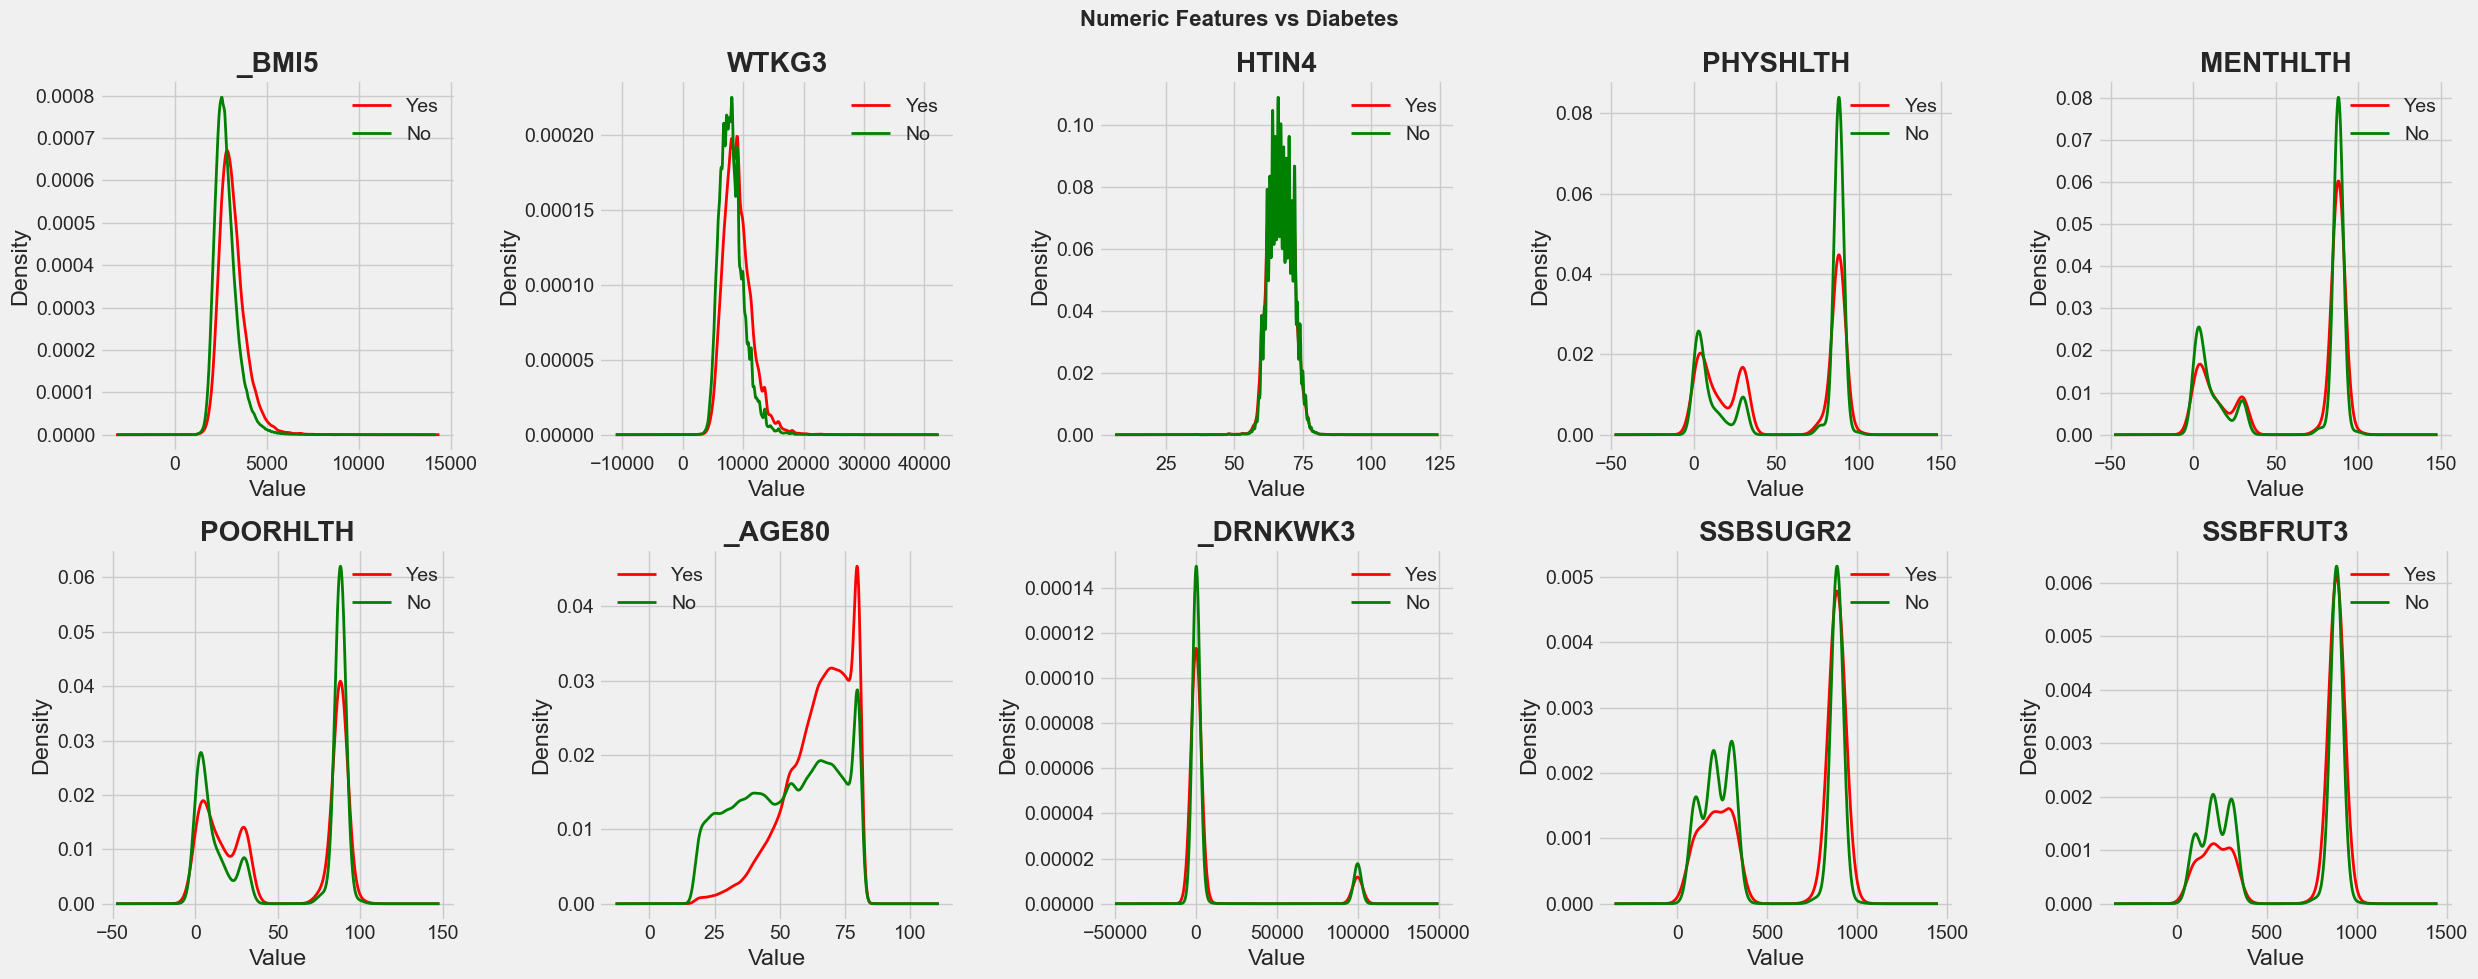

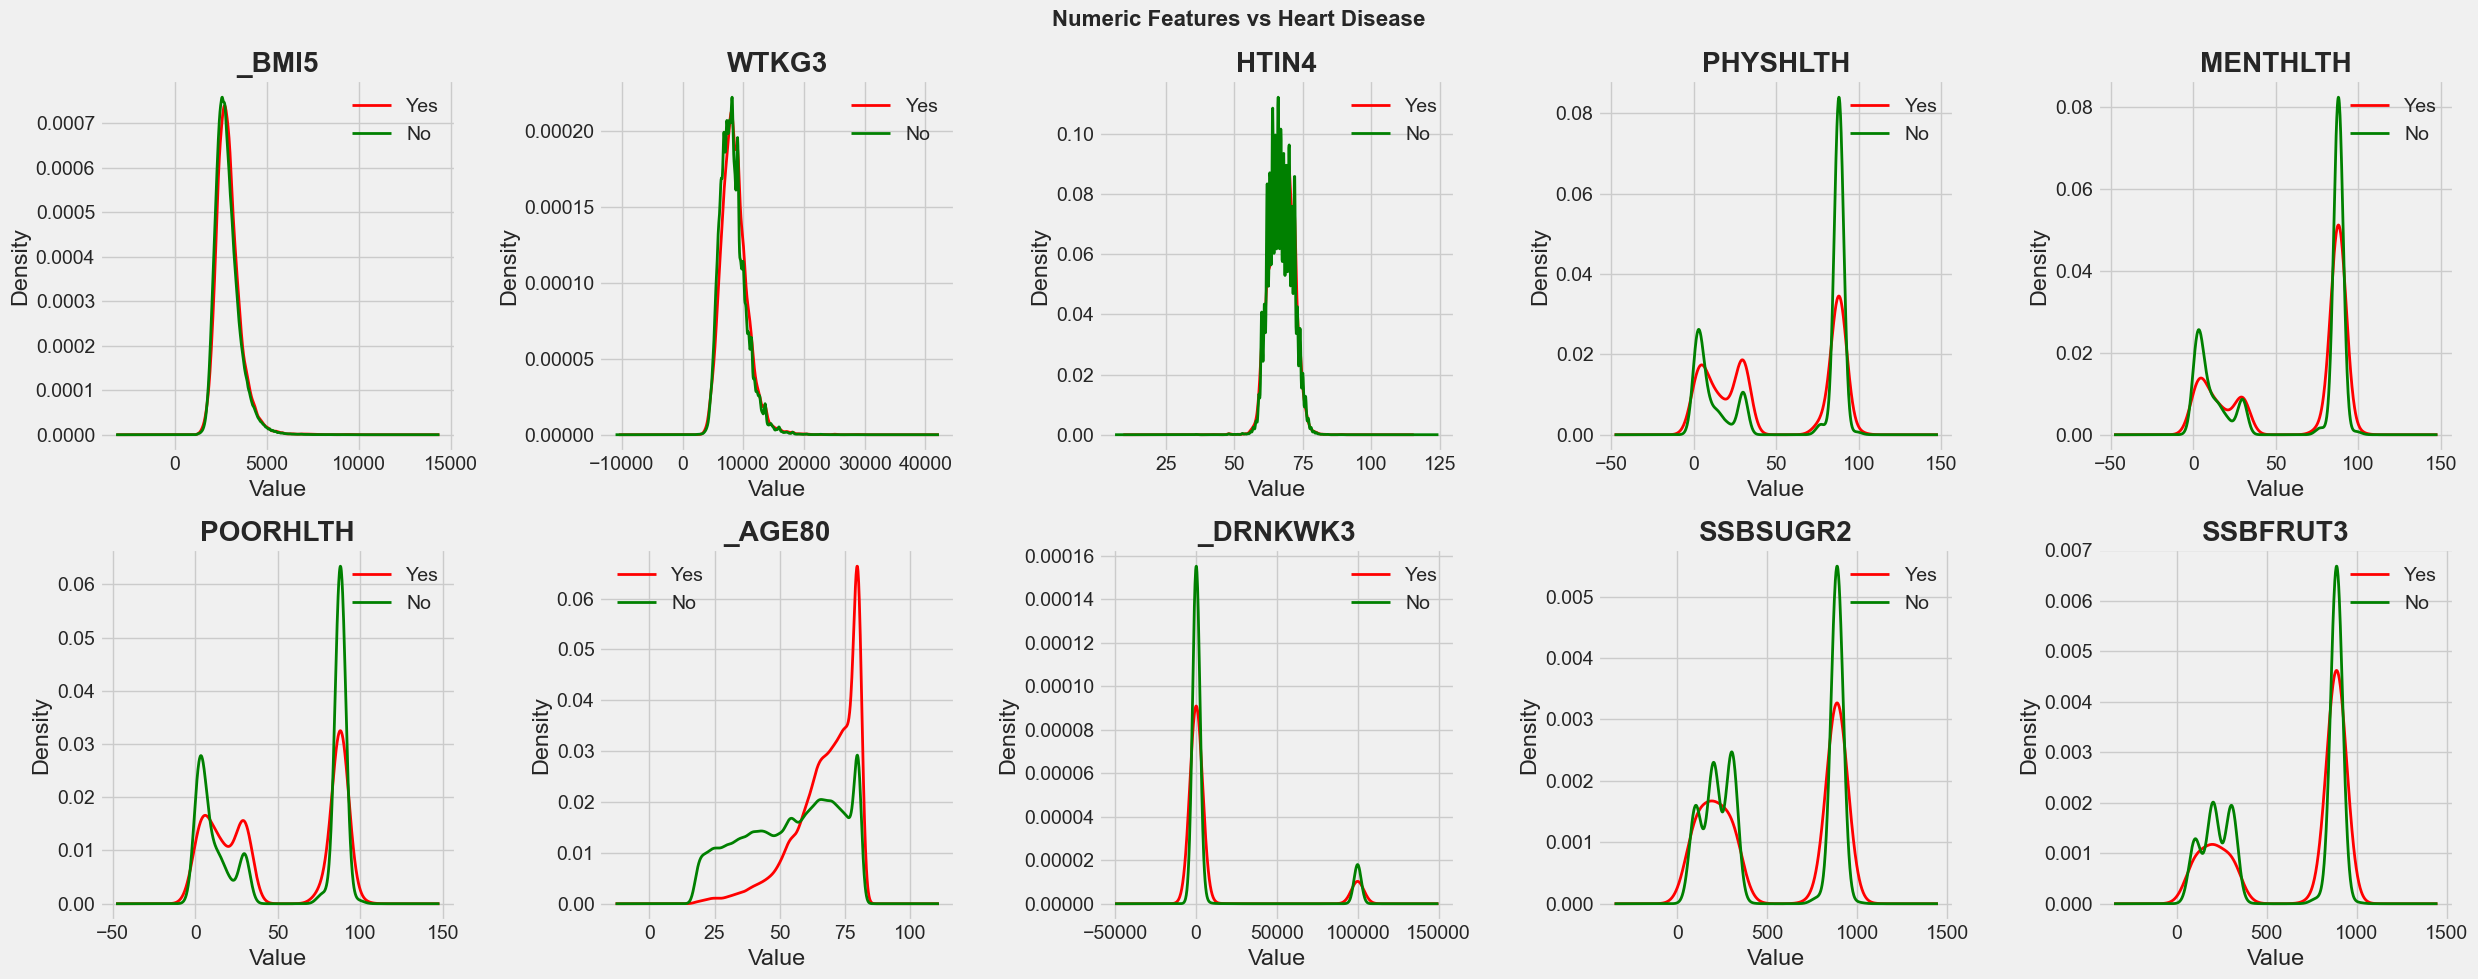

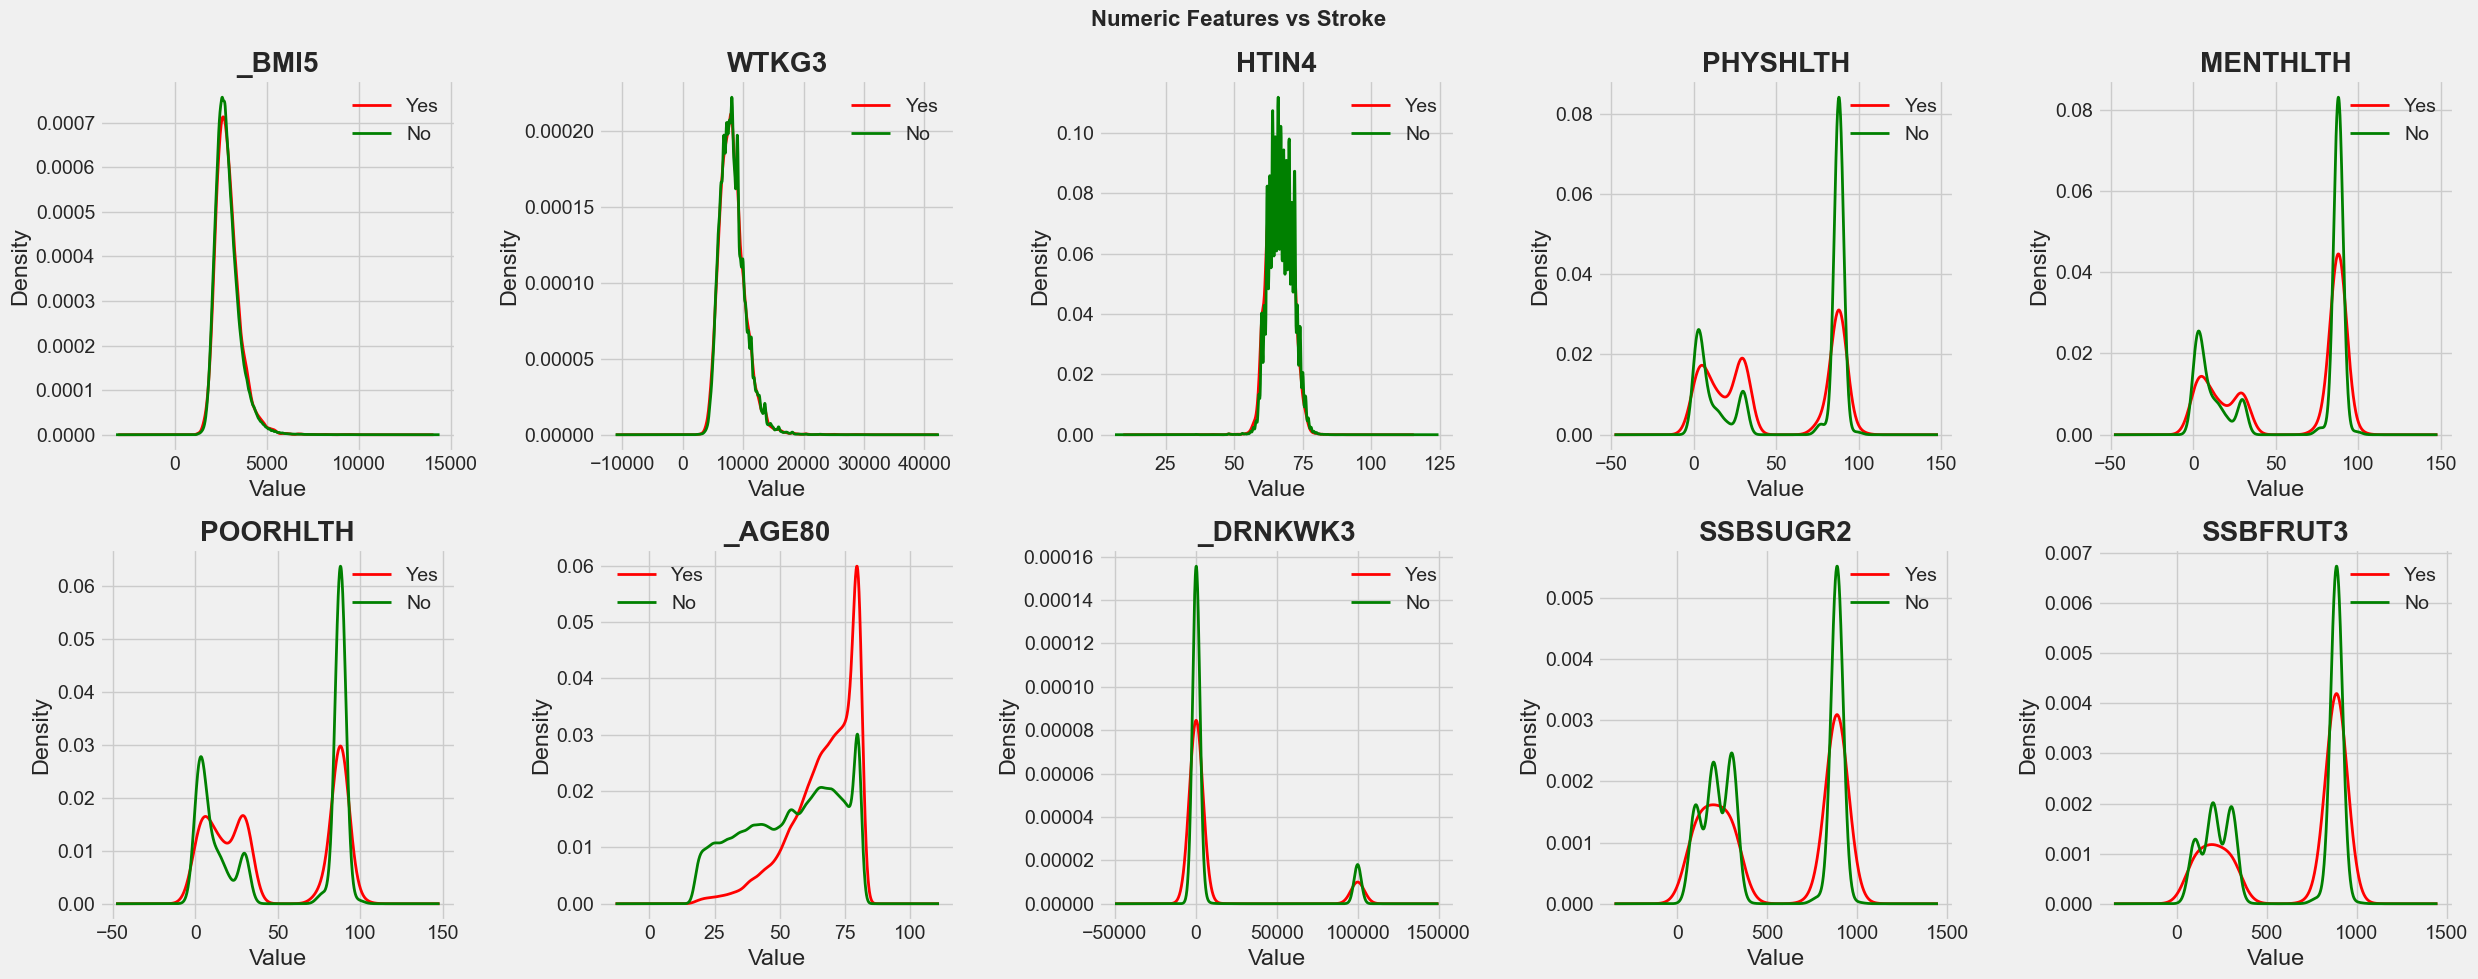

In [68]:
target_values = {
    'DIABETE4': {'yes': 1.0, 'no': 3.0},
    'CVDINFR4': {'yes': 1.0, 'no': 2.0},
    'CVDSTRK3': {'yes': 1.0, 'no': 2.0},
}

for target, tname in zip(['DIABETE4', 'CVDINFR4', 'CVDSTRK3'], ['Diabetes', 'Heart Disease', 'Stroke']):
    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    axes = axes.flatten()

    yes_val = target_values[target]['yes']
    no_val = target_values[target]['no']

    for i, col in enumerate(key_numeric_cols):
        for val, label, color in zip([yes_val, no_val], ['Yes', 'No'], ['red', 'green']):
            subset = df[df[target] == val][col].dropna()
            subset.plot.kde(ax=axes[i], label=label, color=color, linewidth=2)
        axes[i].set_title(f'{col}', fontweight='bold')
        axes[i].set_xlabel('Value')
        axes[i].legend()

    plt.suptitle(f'Numeric Features vs {tname}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()